# PakIT Benchmark
## Exploratory Data Analysis 
### Data Discovery

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv(r"C:\Users\welcome\OneDrive\Desktop\PakIistan IT Universities  Benchmark Project\PakIT_Benchmarks_dataset.csv")
df.head()

,University Name,Campus Location,QS World University Ranking (2026),Institution Type,Annual Academic Cost (PKR),Citations Per Paper,Academic Reputation,International Research Network,Employer Reputation
0,National University of Sciences and Technology...,Islamabad,114,Public,"404,100",83.8,54.4,84.8,66.8
1,COMSATS University Islamabad,Islamabad,180,Public,"321,000",88.8,47.5,92.1,59.3
2,University of Engineering & Technology (UET) L...,Lahore,351-400,Public,"137,244",80.5,42.5,62.5,59.3
3,University of the Punjab,Lahore,351-400,Public,"130,100",84.7,40.9,59.8,59.0
4,Lahore University of Management Sciences (LUMS),Lahore,401-450,Private,"1,938,600",60.1,49.5,29.2,63.2


In [3]:
df.shape

(15, 9)

In [4]:
df.size

135

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   University Name                       15 non-null     str    
 1   Campus Location                       15 non-null     str    
 2    QS World University Ranking (2026)   15 non-null     str    
 3   Institution Type                      15 non-null     str    
 4   Annual Academic Cost (PKR)            14 non-null     str    
 5    Citations Per Paper                  15 non-null     float64
 6    Academic Reputation                  15 non-null     float64
 7    International Research Network       15 non-null     float64
 8   Employer Reputation                   15 non-null     float64
dtypes: float64(4), str(5)
memory usage: 2.2 KB


In [6]:
print(df.isnull().sum())

University Name                         0
Campus Location                         0
 QS World University Ranking (2026)     0
Institution Type                        0
Annual Academic Cost (PKR)              1
 Citations Per Paper                    0
 Academic Reputation                    0
 International Research Network         0
Employer Reputation                     0
dtype: int64


In [7]:
df.columns

Index(['University Name ', 'Campus Location',
       ' QS World University Ranking (2026) ', 'Institution Type',
       'Annual Academic Cost (PKR)', ' Citations Per Paper',
       ' Academic Reputation', ' International Research Network',
       'Employer Reputation'],
      dtype='str')

In [8]:
df.tail

<bound method NDFrame.tail of                                      University Name  Campus Location  \
0   National University of Sciences and Technology...       Islamabad   
1                       COMSATS University Islamabad       Islamabad    
2   University of Engineering & Technology (UET) L...         Lahore    
3                           University of the Punjab          Lahore    
4     Lahore University of Management Sciences (LUMS)         Lahore    
5                            Quaid-i-Azam University        Islamabad   
6              Bahria University, Islamabad.Pakistan        Islamabad   
7   Ghulam Ishaq Khan (GIK), Institute of Engineer...            Topi   
8                            The University of Lahore         Lahore    
9                            Air University Pakistan       Islamabad    
10  National University of Computer and Emerging S...       Islamabad   
11  Pakistan Institute of Engineering and Applied ...       Islamabad   
12  International Isl

In [9]:
df["Institution Type"].value_counts()

Institution Type
Public      10
Private      5
Name: count, dtype: int64

In [10]:
df['Annual Academic Cost (PKR)'].value_counts()

Annual Academic Cost (PKR)
404,100      1
321,000      1
137,244      1
130,100      1
1,938,600    1
121,720      1
390,268      1
940,000      1
389,800      1
292,800      1
437,000      1
193,400      1
187,960      1
195,600      1
Name: count, dtype: int64

In [11]:
df.describe()

,Citations Per Paper,Academic Reputation,International Research Network,Employer Reputation
count,15.000000,15.000000,15.000000,15.000000
mean,77.426667,40.073333,57.646667,53.433333
std,9.426972,7.323881,17.298549,7.782275
min,59.100000,27.900000,29.200000,37.800000
25%,72.900000,34.700000,47.700000,46.900000
50%,81.300000,39.100000,59.100000,54.600000
75%,83.600000,44.750000,63.900000,59.150000
max,88.800000,54.400000,92.100000,66.800000


In [12]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
dtype: bool

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Institution Type'].unique()

<ArrowStringArray>
['Public', 'Private ']
Length: 2, dtype: str

### Data Structuring and Cleaning 

In [15]:
# Mapping strings of 'Institution Type' column
institution_mapping= {
    'Public': 0,
    'Private ': 1
} 
df['Institution_Type_Encoded']= df['Institution Type'].map(institution_mapping)
df.head()

,University Name,Campus Location,QS World University Ranking (2026),Institution Type,Annual Academic Cost (PKR),Citations Per Paper,Academic Reputation,International Research Network,Employer Reputation,Institution_Type_Encoded
0,National University of Sciences and Technology...,Islamabad,114,Public,"404,100",83.8,54.4,84.8,66.8,0
1,COMSATS University Islamabad,Islamabad,180,Public,"321,000",88.8,47.5,92.1,59.3,0
2,University of Engineering & Technology (UET) L...,Lahore,351-400,Public,"137,244",80.5,42.5,62.5,59.3,0
3,University of the Punjab,Lahore,351-400,Public,"130,100",84.7,40.9,59.8,59.0,0
4,Lahore University of Management Sciences (LUMS),Lahore,401-450,Private,"1,938,600",60.1,49.5,29.2,63.2,1


In [16]:
# Mapping QS World University Ranking (2026) column's catagories into its midpoints
ranking_mapping= {
    '114': 114,
    '180': 180,
    '351-400': 375.5,
    '401-450': 425.5,
    '601-650': 625.5,
    '651-700': 675.5,
    '701-750': 725.5,
    '751-850': 800.5
} 
df['QS_Ranking_Midpoints']= df[' QS World University Ranking (2026) '].map(ranking_mapping)
df.head()

,University Name,Campus Location,QS World University Ranking (2026),Institution Type,Annual Academic Cost (PKR),Citations Per Paper,Academic Reputation,International Research Network,Employer Reputation,Institution_Type_Encoded,QS_Ranking_Midpoints
0,National University of Sciences and Technology...,Islamabad,114,Public,"404,100",83.8,54.4,84.8,66.8,0,114.0
1,COMSATS University Islamabad,Islamabad,180,Public,"321,000",88.8,47.5,92.1,59.3,0,180.0
2,University of Engineering & Technology (UET) L...,Lahore,351-400,Public,"137,244",80.5,42.5,62.5,59.3,0,375.5
3,University of the Punjab,Lahore,351-400,Public,"130,100",84.7,40.9,59.8,59.0,0,375.5
4,Lahore University of Management Sciences (LUMS),Lahore,401-450,Private,"1,938,600",60.1,49.5,29.2,63.2,1,425.5


In [17]:
# Removing commas from Annual Academic Cost (PKR) column
df['Annual Academic Cost (PKR)']= (
    df['Annual Academic Cost (PKR)']
    .astype(str)
    .str.replace(',','', regex= False)
) 
df.head()

,University Name,Campus Location,QS World University Ranking (2026),Institution Type,Annual Academic Cost (PKR),Citations Per Paper,Academic Reputation,International Research Network,Employer Reputation,Institution_Type_Encoded,QS_Ranking_Midpoints
0,National University of Sciences and Technology...,Islamabad,114,Public,404100,83.8,54.4,84.8,66.8,0,114.0
1,COMSATS University Islamabad,Islamabad,180,Public,321000,88.8,47.5,92.1,59.3,0,180.0
2,University of Engineering & Technology (UET) L...,Lahore,351-400,Public,137244,80.5,42.5,62.5,59.3,0,375.5
3,University of the Punjab,Lahore,351-400,Public,130100,84.7,40.9,59.8,59.0,0,375.5
4,Lahore University of Management Sciences (LUMS),Lahore,401-450,Private,1938600,60.1,49.5,29.2,63.2,1,425.5


In [18]:
#Converting Annual Academic Cost dtype from str to numeric for sorting NAN 
df['Annual Academic Cost (PKR)']= pd.to_numeric(df['Annual Academic Cost (PKR)'],
errors= "coerce"                #If pandas finds a value that cannot be converted into a number, instead of giving  an error, convert that value into NaN.
)
df['Annual Academic Cost (PKR)'].head()


0     404100.0
1     321000.0
2     137244.0
3     130100.0
4    1938600.0
Name: Annual Academic Cost (PKR), dtype: float64

In [19]:
#filling NAN with mean of the column 
df['Annual Academic Cost (PKR)']= df['Annual Academic Cost (PKR)'].fillna(
    df['Annual Academic Cost (PKR)'].mean()
)
df['Annual Academic Cost (PKR)'].head()

0     404100.0
1     321000.0
2     137244.0
3     130100.0
4    1938600.0
Name: Annual Academic Cost (PKR), dtype: float64

In [20]:
df.to_csv('Cleaned Pak IT Benchmark Dataset', index= False)

## Data Validation 

In [21]:
df.shape

(15, 11)

In [22]:
df.dtypes

University Name                             str
Campus Location                             str
 QS World University Ranking (2026)         str
Institution Type                            str
Annual Academic Cost (PKR)              float64
 Citations Per Paper                    float64
 Academic Reputation                    float64
 International Research Network         float64
Employer Reputation                     float64
Institution_Type_Encoded                  int64
QS_Ranking_Midpoints                    float64
dtype: object

In [23]:
df.columns

Index(['University Name ', 'Campus Location',
       ' QS World University Ranking (2026) ', 'Institution Type',
       'Annual Academic Cost (PKR)', ' Citations Per Paper',
       ' Academic Reputation', ' International Research Network',
       'Employer Reputation', 'Institution_Type_Encoded',
       'QS_Ranking_Midpoints'],
      dtype='str')

In [24]:
df.isna().sum()

University Name                         0
Campus Location                         0
 QS World University Ranking (2026)     0
Institution Type                        0
Annual Academic Cost (PKR)              0
 Citations Per Paper                    0
 Academic Reputation                    0
 International Research Network         0
Employer Reputation                     0
Institution_Type_Encoded                0
QS_Ranking_Midpoints                    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df[["Institution Type", "Institution_Type_Encoded"]]

,Institution Type,Institution_Type_Encoded
0,Public,0
1,Public,0
2,Public,0
3,Public,0
4,Private,1
5,Public,0
6,Public,0
7,Private,1
8,Private,1
9,Public,0


In [27]:
df[[' QS World University Ranking (2026) ','QS_Ranking_Midpoints']]

,QS World University Ranking (2026),QS_Ranking_Midpoints
0,114,114.0
1,180,180.0
2,351-400,375.5
3,351-400,375.5
4,401-450,425.5
5,401-450,425.5
6,601-650,625.5
7,601-650,625.5
8,601-650,625.5
9,651-700,675.5


In [28]:
#Verifying the conversion
df['Annual Academic Cost (PKR)'].to_string(index= False)
df.head()

,University Name,Campus Location,QS World University Ranking (2026),Institution Type,Annual Academic Cost (PKR),Citations Per Paper,Academic Reputation,International Research Network,Employer Reputation,Institution_Type_Encoded,QS_Ranking_Midpoints
0,National University of Sciences and Technology...,Islamabad,114,Public,404100.0,83.8,54.4,84.8,66.8,0,114.0
1,COMSATS University Islamabad,Islamabad,180,Public,321000.0,88.8,47.5,92.1,59.3,0,180.0
2,University of Engineering & Technology (UET) L...,Lahore,351-400,Public,137244.0,80.5,42.5,62.5,59.3,0,375.5
3,University of the Punjab,Lahore,351-400,Public,130100.0,84.7,40.9,59.8,59.0,0,375.5
4,Lahore University of Management Sciences (LUMS),Lahore,401-450,Private,1938600.0,60.1,49.5,29.2,63.2,1,425.5


In [29]:
df['Annual Academic Cost (PKR)'].describe

<bound method NDFrame.describe of 0     4.041000e+05
1     3.210000e+05
2     1.372440e+05
3     1.301000e+05
4     1.938600e+06
5     1.217200e+05
6     3.902680e+05
7     9.400000e+05
8     3.898000e+05
9     2.928000e+05
10    4.370000e+05
11    1.934000e+05
12    1.879600e+05
13    1.956000e+05
14    4.342566e+05
Name: Annual Academic Cost (PKR), dtype: float64>

### Data Visualization 

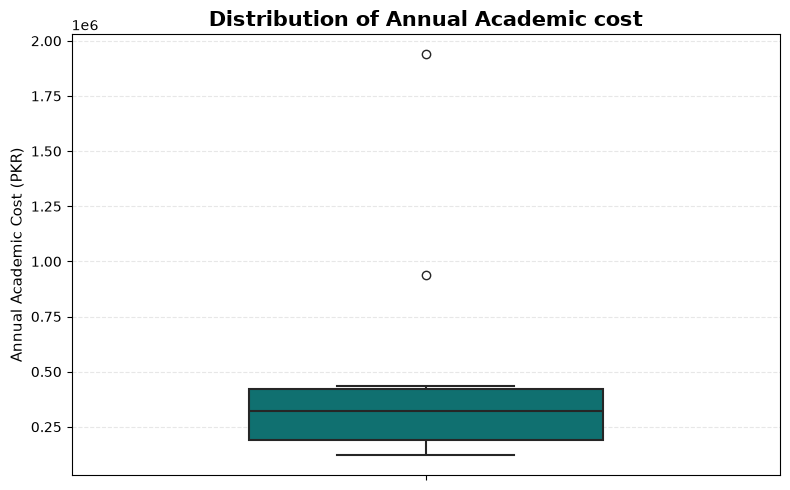

In [30]:
# Creating box plot
plt.figure(figsize= (8,5))

sns.boxplot(
    data= df,
    y= 'Annual Academic Cost (PKR)',
    width= 0.5,
    linewidth= 1.5,
    fliersize= 6,
    color= 'Teal'
)
plt.title(
    'Distribution of Annual Academic cost',
    fontsize= 15,
    fontweight= "bold"
)
plt.ylabel(
    "Annual Academic Cost (PKR)",
    fontsize= 11
)
plt.grid(axis='y', linestyle='--', alpha=0.3)    #alpha= Transparency of lines; 1.0= completely opqaue, 0= invisible
plt.tight_layout()
plt.show()


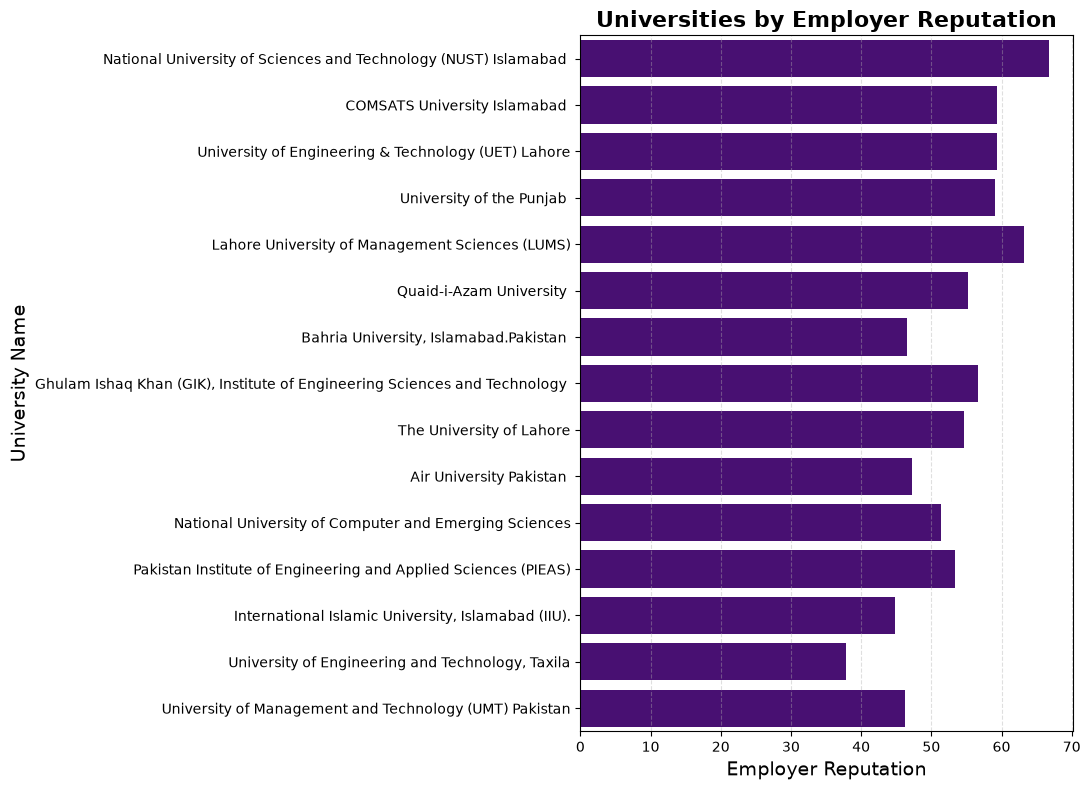

In [31]:
plt.figure(figsize= (11,8))
sns.barplot(
    data=df,
    y="University Name ",
    x="Employer Reputation",
    color="Indigo"
)
plt.title(
    "Universities by Employer Reputation",
    fontsize= 16,
    fontweight= 'bold'
)
plt.xlabel(
    "Employer Reputation",
    fontsize= 14
)
plt.ylabel('University Name', fontsize= 14)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
df.sort_values('Employer Reputation', ascending= True)
plt.tight_layout()            #automatically adjusts the spacing around your plot
plt.show() 


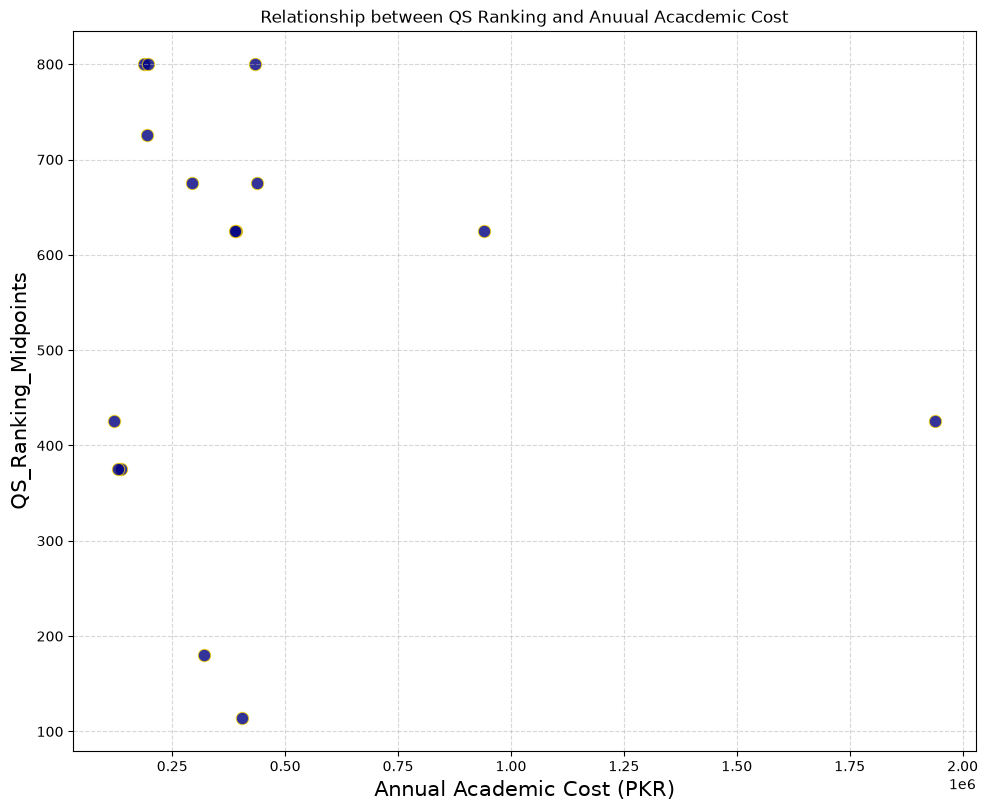

In [32]:
#Relationship between QS ranking and Annual Academic Cost 
plt.figure(figsize= (10,8))
sns.scatterplot(
    data= df,
    x= 'Annual Academic Cost (PKR)',
    y= 'QS_Ranking_Midpoints',
    color= 'Navy',
    edgecolor= 'Gold',
    s= 80,              #size of marker dot
    alpha= 0.8
)
plt.xlabel('Annual Academic Cost (PKR)', fontsize= 15)
plt.ylabel('QS_Ranking_Midpoints', fontsize= 15)
plt.grid(
    axis= 'both',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.title('Relationship between QS Ranking and Anuual Acacdemic Cost')
plt.show()

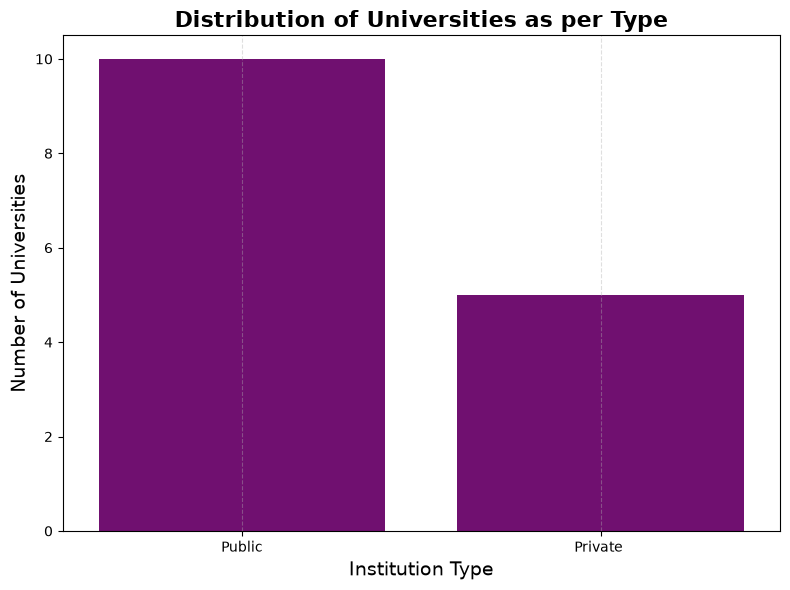

In [33]:
#How many Universities are public and private?
plt.figure(figsize= (8,6))
sns.countplot(
    data= df,
    x= "Institution Type",
    color= 'Purple'
)
plt.title('Distribution of Universities as per Type', fontsize= 16, fontweight= 'bold')
plt.xlabel('Institution Type', fontsize= 14)
plt.ylabel('Number of Universities', fontsize= 14)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

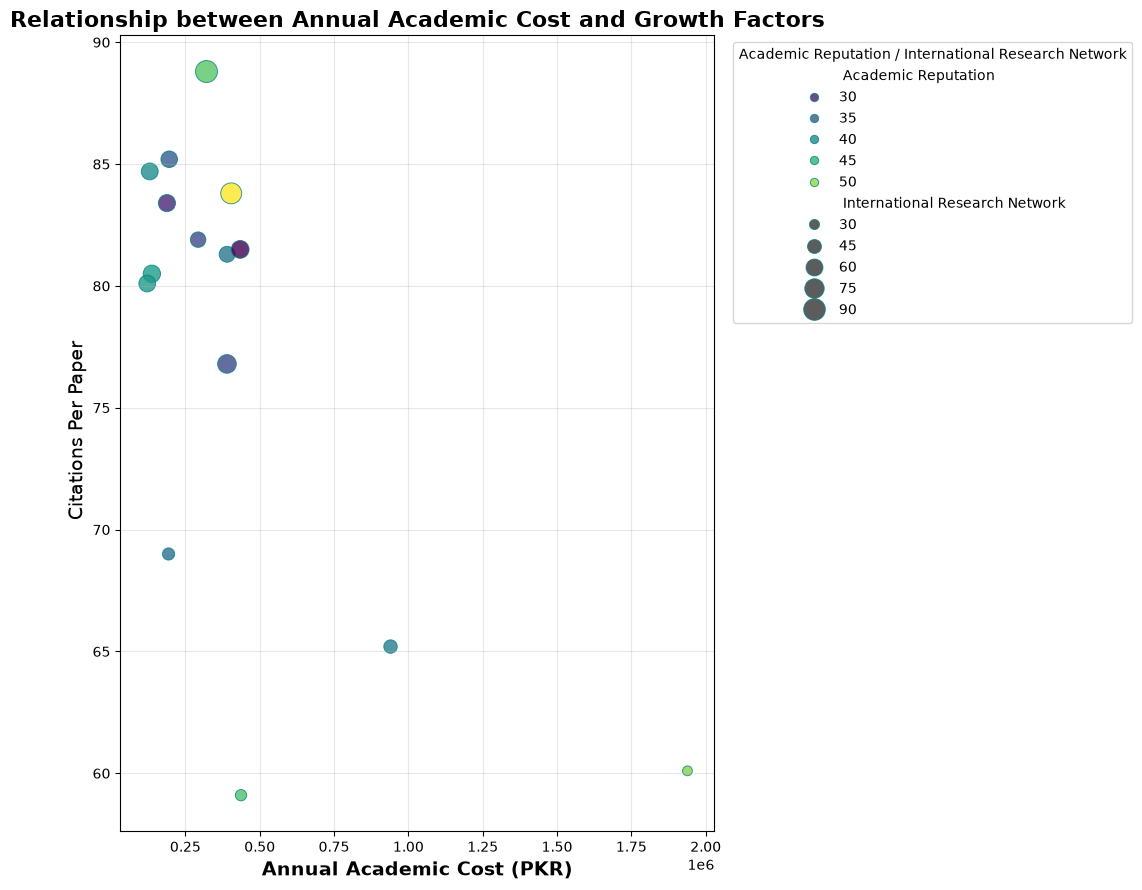

In [34]:
#How does Annual Academic Cost Contributr to the Growth Factors? 
plt.figure(figsize= (11, 9))
sns.scatterplot(
    data= df,
    x= 'Annual Academic Cost (PKR)',
    y= ' Citations Per Paper',
    hue= ' Academic Reputation',
    size= ' International Research Network', 
    #universities with different International Research Network scores will have different-sized dots
    sizes= (50, 250),        #controlling the visual size
    palette= "viridis",     #represents color of x
    alpha= 0.8,
    edgecolor= 'Teal'
)
plt.xlabel(
    'Annual Academic Cost (PKR)', 
    fontsize= 14, 
    fontweight= 'bold'
)
plt.ylabel(
    ' Citations Per Paper', 
    fontsize= 14
)
plt.title(
    'Relationship between Annual Academic Cost and Growth Factors', 
    fontsize= 16, 
    fontweight= 'bold'
)
plt.grid(
    axis= 'both', 
    linestyle= '-',
    alpha= 0.3
)
plt.legend(
    bbox_to_anchor= (1.02, 1),
    loc= 'upper left',
    title= 'Academic Reputation / International Research Network'
)
plt.tight_layout()
plt.show()        

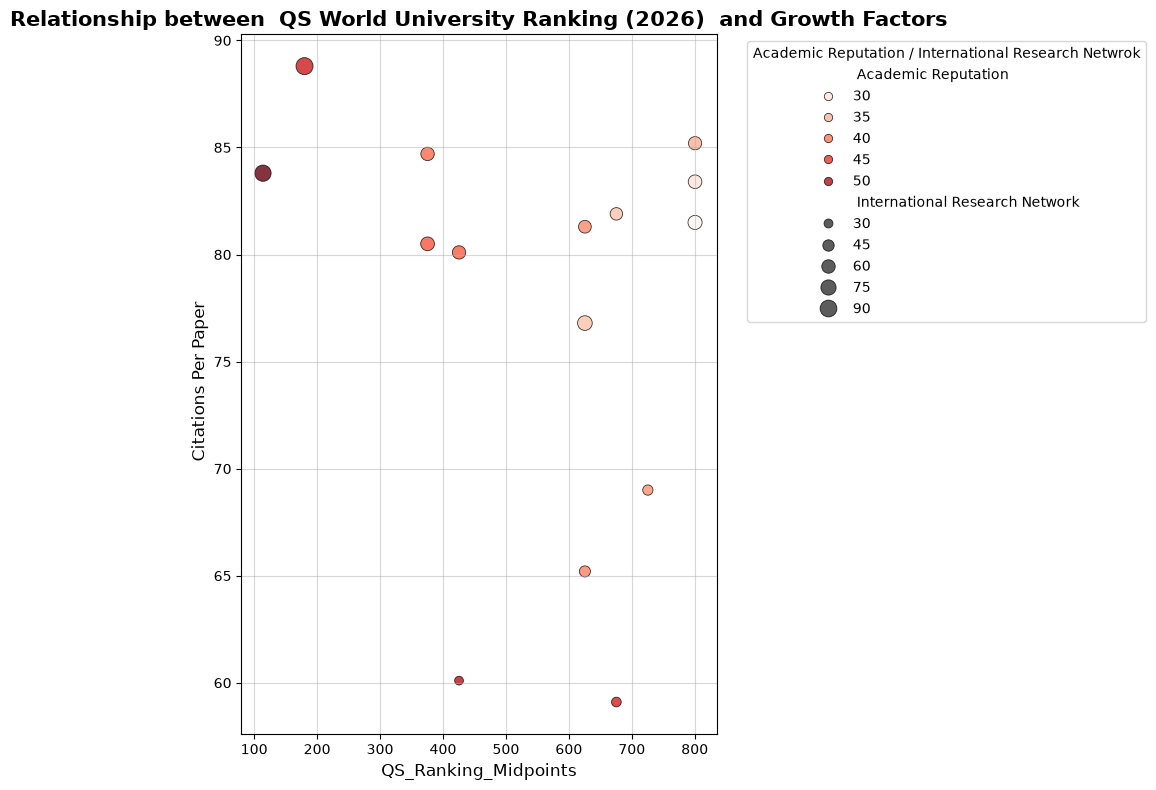

In [35]:
#How QS World Rankings Contribute to Growth Factors?
plt.figure(figsize= (10,8))
sns.scatterplot(
    data= df,
    x= 'QS_Ranking_Midpoints',
    y= ' Citations Per Paper',
    hue= ' Academic Reputation',
    size= ' International Research Network',
    palette= 'Reds',
    edgecolor= 'Black',
    sizes= (40,150),
    alpha= 0.8
)
plt.xlabel(
    'QS_Ranking_Midpoints', 
    fontsize= 12
)
plt.ylabel(
    ' Citations Per Paper',
    fontsize= 12
)
plt.title(
    'Relationship between  QS World University Ranking (2026)  and Growth Factors',
    fontsize= 15, 
    fontweight= 'bold'
)
plt.legend(
    bbox_to_anchor= (1.05, 1),     #1.05:place legend to slightly right  1: top
    loc= 'upper left',
    title= 'Academic Reputation / International Research Netwrok'
)
plt.grid(
    axis= 'both',
    linestyle= '-',
    alpha= 0.5
)
plt.tight_layout()
plt.show()       

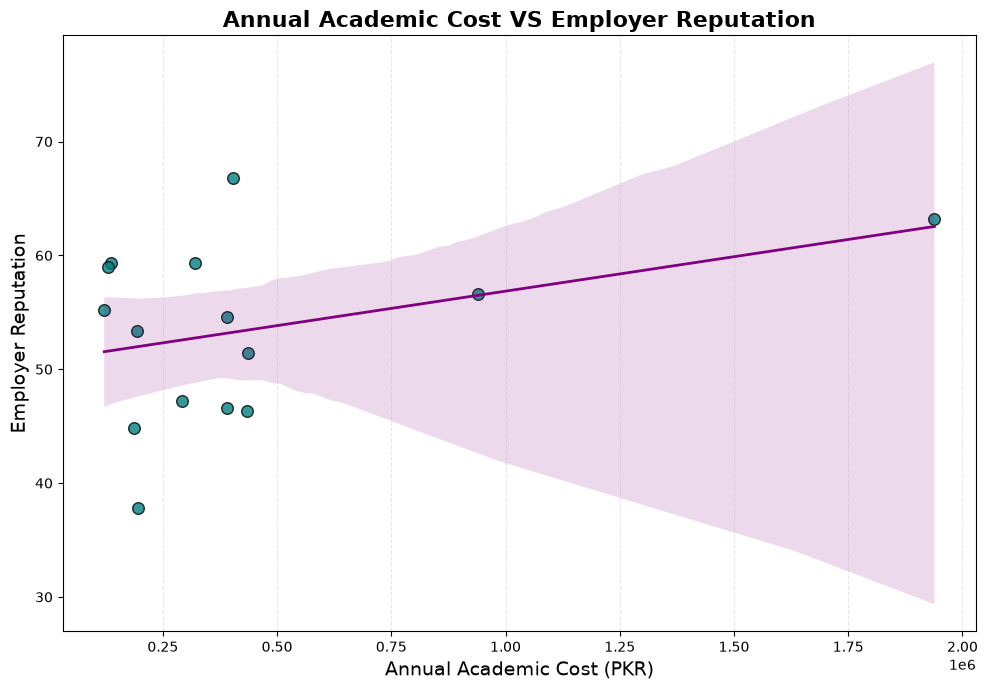

In [36]:
#Regression Plot
plt.figure(figsize= (10,7))
sns.regplot(
    data= df,
    x= 'Annual Academic Cost (PKR)',
    y= 'Employer Reputation',
    scatter_kws={
        's': 70,
        'color': 'Teal',
        'edgecolor' : 'Black'
    },
    line_kws= {
        'color': 'Purple',
        'linewidth': 2
    }
)
plt.title(
    'Annual Academic Cost VS Employer Reputation', 
    fontsize= 16,
    fontweight= 'bold'
)
plt.xlabel(
    'Annual Academic Cost (PKR)',
    fontsize= 14
)
plt.ylabel(
    'Employer Reputation',
    fontsize= 14
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.3
)
plt.tight_layout()
plt.show()


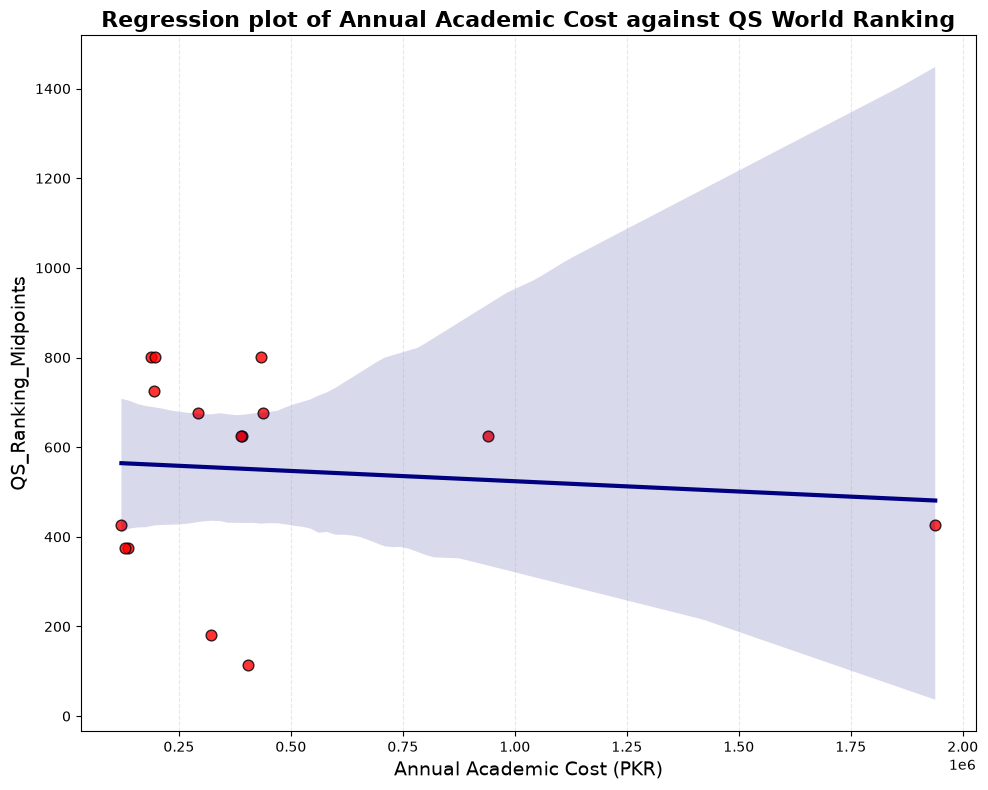

In [37]:
plt.figure(figsize= (10,8))
sns.regplot(
    data= df,
    x= 'Annual Academic Cost (PKR)',
    y= 'QS_Ranking_Midpoints',
    scatter_kws= {
        's': 60,
        'color': 'red',
        'edgecolor' : 'Black'
    },
    line_kws={
        'color': 'navy',
        'linewidth' : 3
    }
)
plt.title(
    'Regression plot of Annual Academic Cost against QS World Ranking',
    fontsize= 16,
    fontweight= 'bold'
)
plt.xlabel(
    'Annual Academic Cost (PKR)',
    fontsize= 14
)
plt.ylabel(
    'QS_Ranking_Midpoints',
    fontsize= 14
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.3
)
plt.tight_layout()
plt.show()

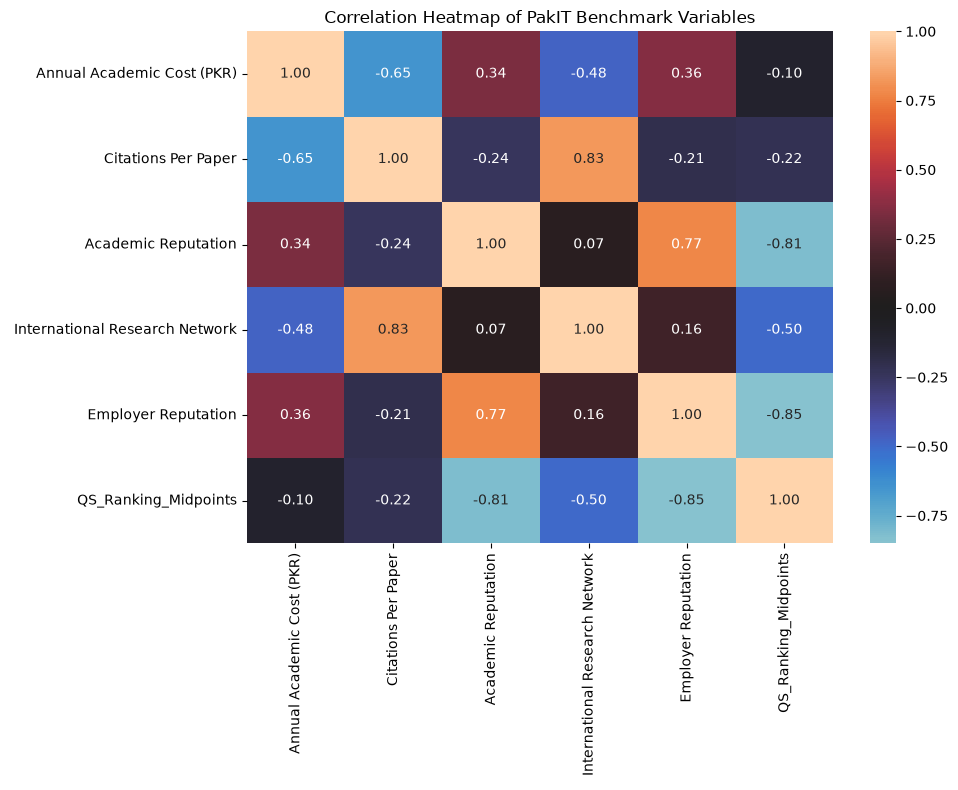

In [38]:
#creating histogram
plt.figure(figsize= (10,8))
sns.heatmap(
    df[
        [
            'Annual Academic Cost (PKR)',
            ' Citations Per Paper',
            ' Academic Reputation',
            ' International Research Network',
            'Employer Reputation',
            'QS_Ranking_Midpoints'
        ]
    ].corr(),         #calculates the correlation between every pair of numerical variables + colors by default
    annot= True,      #annot:> annotation, displays the numerical values inside the heatmap cells.
    fmt= ".2f",       #rounds off the corr values upto 2 decimal values
    center= 0         #Treat 0 as the center of the color scale.
)
plt.title("Correlation Heatmap of PakIT Benchmark Variables")
plt.tight_layout()
plt.show()

#+1 → strong positive relationship
#0 → no linear relationship
#-1 → strong negative relationship

### Statistical Data Analysis and Result Interpretation 

In [39]:
#Performing correlation analysis
from scipy.stats import pearsonr
r, p= pearsonr(
    df['Annual Academic Cost (PKR)'],
    df['Employer Reputation']
)
#Hypotheses
print("H0:There is no significant linear correlation between Annual Academic Cost and Employer Reputation.")
print("H1: There is a significant linear correlation between Annual Academic Cost and Employer Reputation.")
#Result
print("Pearson Correlation (r): ", r.round(3))
print("P-value: ", p.round(4))
#significance level
alpha= 0.05
if p< alpha:
    print('Decision: Reject H0')
    print("Conclusion: There is a significant linear correlation between Annual Academic Cost and Employer Reputation.")
else: 
    print('Decision: Fail to reject H0')
    print("Conclusion: There is no significant linear correlation between Annual Academic Cost and Employer Reputation.")


H0:There is no significant linear correlation between Annual Academic Cost and Employer Reputation.
H1: There is a significant linear correlation between Annual Academic Cost and Employer Reputation.
Pearson Correlation (r):  0.361
P-value:  0.1864
Decision: Fail to reject H0
Conclusion: There is no significant linear correlation between Annual Academic Cost and Employer Reputation.


In [40]:
from scipy.stats import pearsonr
r, p= pearsonr(
    df['Annual Academic Cost (PKR)'],
    df[' Academic Reputation']
)
#Hypotheses
print("H0:There is no significant linear correlation between Annual Academic Cost and Academic Reputation.")
print("H1: There is a significant linear correlation between Annual Academic Cost and Academic Reputation.")
#Result
print("Pearson Correlation (r): ", r.round(3))
print("P-value: ", p.round(4))
#significance level
alpha= 0.05
if p< alpha:
    print('Decision: Reject H0')
    print("Conclusion: There is  significant linear correlation between Annual Academic Cost and Academic Reputation.")
else: 
    print('Decision: Fail to reject H0')
    print("Conclusion: There is no significant linear correlation between Annual Academic Cost and Academic Reputation.")


H0:There is no significant linear correlation between Annual Academic Cost and Academic Reputation.
H1: There is a significant linear correlation between Annual Academic Cost and Academic Reputation.
Pearson Correlation (r):  0.336
P-value:  0.2201
Decision: Fail to reject H0
Conclusion: There is no significant linear correlation between Annual Academic Cost and Academic Reputation.


In [41]:
from scipy.stats import pearsonr
r,p = pearsonr (
    df['Annual Academic Cost (PKR)'],
    df[' Citations Per Paper']
)
#Hypotheses
print('H0: There is no significant relationship between Annual Academic Cost and Citations Per Paper.')
print('H1: There is significant relationship between Annual Academic Cost and Citations Per Paper.')
#Result
print('Pearson Correlation (r): ', round(r, 3))
print('P-value (p): ', round(p, 4))
#Significance level
alpha= 0.05
if p< alpha: 
    print('Decision: Rejected H0')
    print('Conclusion: There is significant relationship between Annual Academic Cost and Citations Per Paper.')
else: 
    print('Decision: Fail to reject H0')
    print('Conclusion: There is a no significant relationship between Annual Academic Cost and Citations Per Paper.')
    #negative linear relationship

H0: There is no significant relationship between Annual Academic Cost and Citations Per Paper.
H1: There is significant relationship between Annual Academic Cost and Citations Per Paper.
Pearson Correlation (r):  -0.651
P-value (p):  0.0086
Decision: Rejected H0
Conclusion: There is significant relationship between Annual Academic Cost and Citations Per Paper.


In [42]:
df.columns

Index(['University Name ', 'Campus Location',
       ' QS World University Ranking (2026) ', 'Institution Type',
       'Annual Academic Cost (PKR)', ' Citations Per Paper',
       ' Academic Reputation', ' International Research Network',
       'Employer Reputation', 'Institution_Type_Encoded',
       'QS_Ranking_Midpoints'],
      dtype='str')

In [43]:
#Regression Analysis of regplot 1
from scipy.stats import linregress
x= df['Annual Academic Cost (PKR)']
y=df['Employer Reputation']
result= linregress(x, y)
print('Slope: ', result.slope)
print('Intercept: ', result.intercept)
print('R-Squared: ', result.rvalue**2)
print('P-Value: ', result.pvalue)

Slope:  6.055058756584041e-06
Intercept:  50.803884277900586
R-Squared:  0.1301781972710755
P-Value:  0.18643919495900044


In [44]:
#Regression Analysis of regplot 2
from scipy.stats import linregress
x= df['Annual Academic Cost (PKR)']
y= df['QS_Ranking_Midpoints']
result= linregress(x, y)
print('Slope: ', result.slope)
print('Intercept: ', result.intercept.round(3))
print('R-Squared: ', result.rvalue**2)
print('P-Value: ', result.pvalue.round(2))

Slope:  -4.586447491224565e-05
Intercept:  569.95
R-Squared:  0.00922409814317322
P-Value:  0.73


In [45]:
from scipy.stats import mannwhitneyu

print('H0: There is no significant difference in annual academic cost between public and private universities.')
print('H1: There is a significant difference in annual academic cost between public and private universities.')
alpha= 0.05

public = df[df['Institution_Type_Encoded'] == 0]['Annual Academic Cost (PKR)']
private = df[df['Institution_Type_Encoded'] == 1]['Annual Academic Cost (PKR)']

statistic, p_value= mannwhitneyu(
    public,
    private,
    alternative= 'two-sided'
)

print('U Statistics: ', statistic)
print('P-Value: ', p_value.round(3))

if p_value < alpha:
    print('Decision: Reject H0')
    print('There is a significant difference in annual academic cost between public and private universities.')
else: 
    print('Decision: Fail To Reject H0')
    print('There is no significant difference in annual academic cost between public and private universities.')

H0: There is no significant difference in annual academic cost between public and private universities.
H1: There is a significant difference in annual academic cost between public and private universities.
U Statistics:  2.0
P-Value:  0.003
Decision: Reject H0
There is a significant difference in annual academic cost between public and private universities.
